# Assignment 1: ICU Mortality Prediction

Author:  
Ismail Mohammed

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import joblib

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load dataset

In [3]:
mortality_ori = pd.read_csv('raw_data/training_v2.csv')
mortality = mortality_ori.copy()

In [4]:
mortality.head()

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


In [6]:
mortality.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 186 columns):
 #    Column                         Non-Null Count  Dtype  
---   ------                         --------------  -----  
 0    encounter_id                   91713 non-null  int64  
 1    patient_id                     91713 non-null  int64  
 2    hospital_id                    91713 non-null  int64  
 3    hospital_death                 91713 non-null  int64  
 4    age                            87485 non-null  float64
 5    bmi                            88284 non-null  float64
 6    elective_surgery               91713 non-null  int64  
 7    ethnicity                      90318 non-null  object 
 8    gender                         91688 non-null  object 
 9    height                         90379 non-null  float64
 10   hospital_admit_source          70304 non-null  object 
 11   icu_admit_source               91601 non-null  object 
 12   icu_id                        

## Task 1: Data Cleaning

### Visualize missing values

I started off with pulling up all the columns with 75% missing information but also all the ones with the words invasive and noninvasive. I then saved those columns in a separate array so that I could remove those columns later.

In [5]:
cols_to_drop = []
invasive_cols = []
for col in mortality.columns:
    pct = mortality[col].isna().mean() * 100
    if (pct >= 75):
        cols_to_drop.append(col)
        print('{} => {}%'.format(col, round(pct, 2)))
    if ('invasive' in col and pct < 75):
        invasive_cols.append(col)

fio2_apache => 77.27%
paco2_apache => 77.27%
paco2_for_ph_apache => 77.27%
pao2_apache => 77.27%
ph_apache => 77.27%
h1_diasbp_invasive_max => 81.7%
h1_diasbp_invasive_min => 81.7%
h1_mbp_invasive_max => 81.61%
h1_mbp_invasive_min => 81.61%
h1_sysbp_invasive_max => 81.68%
h1_sysbp_invasive_min => 81.68%
h1_albumin_max => 91.4%
h1_albumin_min => 91.4%
h1_bilirubin_max => 92.27%
h1_bilirubin_min => 92.27%
h1_bun_max => 81.88%
h1_bun_min => 81.88%
h1_calcium_max => 82.72%
h1_calcium_min => 82.72%
h1_creatinine_max => 81.73%
h1_creatinine_min => 81.73%
h1_hco3_max => 82.97%
h1_hco3_min => 82.97%
h1_hemaglobin_max => 79.73%
h1_hemaglobin_min => 79.73%
h1_hematocrit_max => 80.05%
h1_hematocrit_min => 80.05%
h1_lactate_max => 91.99%
h1_lactate_min => 91.99%
h1_platelets_max => 82.51%
h1_platelets_min => 82.51%
h1_potassium_max => 78.62%
h1_potassium_min => 78.62%
h1_sodium_max => 79.18%
h1_sodium_min => 79.18%
h1_wbc_max => 82.82%
h1_wbc_min => 82.82%
h1_arterial_pco2_max => 82.82%
h1_arteria

### Clean columns

Here I started off with removing all columns with id:s. That is because the id of the patient, the encounter or the hospital is not a part of the patients health and does not dictate whether or not they live or die. If we were supposed to study the survivability rates in different hospitals it might have been valuable but for this case it is not. 
I also removed two columns that had a death probability number. That is because we do not want the model to take from or learn from another person/models guess. We want our model to learn from the information coming from the patients body and not another ones guess. 

Then I also chose to remove all the columns missing 75% data or more because if we used those columns later on, it would mean that we have to impute the values of 3 out of 4 patients or more and then the variable basically becomes a massive guess. 

Last but not least I also chose to remove all columns with the words invasive and noninvasive. That is because there was always a third column that was a merger of those columns which made the other two redundant. 

In [6]:
mortality.drop(['encounter_id', 'patient_id', 'hospital_id', 'icu_id', "apache_4a_hospital_death_prob", 
                "apache_4a_icu_death_prob"], axis=1, inplace=True)
mortality.drop(cols_to_drop, axis=1, inplace=True)
mortality.drop(invasive_cols, axis=1, inplace=True)

h1_cols = [col for col in mortality.columns if col.startswith('h1')]
mortality.drop(h1_cols, axis=1, inplace=True)

mortality.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 99 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hospital_death               91713 non-null  int64  
 1   age                          87485 non-null  float64
 2   bmi                          88284 non-null  float64
 3   elective_surgery             91713 non-null  int64  
 4   ethnicity                    90318 non-null  object 
 5   gender                       91688 non-null  object 
 6   height                       90379 non-null  float64
 7   hospital_admit_source        70304 non-null  object 
 8   icu_admit_source             91601 non-null  object 
 9   icu_stay_type                91713 non-null  object 
 10  icu_type                     91713 non-null  object 
 11  pre_icu_los_days             91713 non-null  float64
 12  readmission_status           91713 non-null  int64  
 13  weight          

<Axes: >

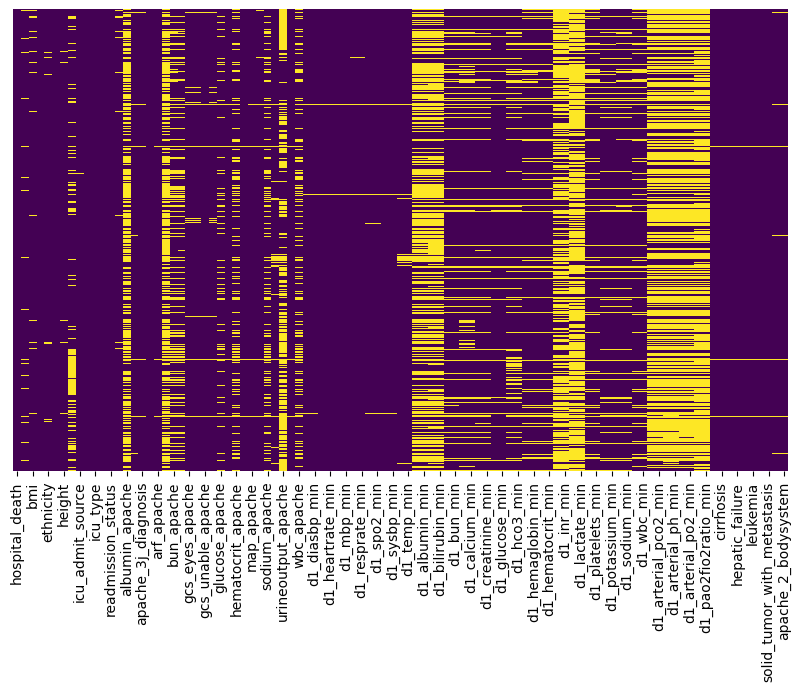

In [ ]:
# visualize null values
plt.figure(figsize=(10, 6))
sns.heatmap(mortality.isnull(), yticklabels=False, cmap='viridis', cbar=False)

## Task 2: Imputation

Split into Training data and Testing data

In [7]:
y = mortality['hospital_death']
X = mortality.drop('hospital_death', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Here I split up the columns in the ones with only numerical values and columns with non-numerical values (object).

In [8]:
cont_feats = X_train.select_dtypes(include=['number']).columns.tolist()
cat_feats = [col for col in X_train.columns if col not in cont_feats and col != 'hospital_death']

if 'hospital_death' in cont_feats:
    cont_feats.remove('hospital_death')

mortality.info(max_cols=150)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 99 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hospital_death               91713 non-null  int64  
 1   age                          87485 non-null  float64
 2   bmi                          88284 non-null  float64
 3   elective_surgery             91713 non-null  int64  
 4   ethnicity                    90318 non-null  object 
 5   gender                       91688 non-null  object 
 6   height                       90379 non-null  float64
 7   hospital_admit_source        70304 non-null  object 
 8   icu_admit_source             91601 non-null  object 
 9   icu_stay_type                91713 non-null  object 
 10  icu_type                     91713 non-null  object 
 11  pre_icu_los_days             91713 non-null  float64
 12  readmission_status           91713 non-null  int64  
 13  weight          

Here I chose median Imputation as my imputation strategy. The reason for that is because of our huge dataset and the amount of datapoints it has. The positive thing with median is if we have an outlier in some of our columns the median would not be as shifted towards tha outlier like the mean imputation might have been. 

In [9]:
# Median Imputation
median_imputer = SimpleImputer(strategy='median')
median_imputer.fit(X_train[cont_feats])

X_train_median = pd.DataFrame(median_imputer.transform(X_train[cont_feats]), columns=cont_feats)
X_test_median = pd.DataFrame(median_imputer.transform(X_test[cont_feats]), columns=cont_feats)

X_train_cat = X_train[cat_feats].fillna('Unknown')
X_test_cat = X_test[cat_feats].fillna('Unknown')

X_train_cat_encoded = pd.get_dummies(X_train_cat, drop_first=True)
X_test_cat_encoded = pd.get_dummies(X_test_cat, drop_first=True)

X_test_cat_encoded = X_test_cat_encoded.reindex(columns=X_train_cat_encoded.columns, fill_value=0)

X_train_final = pd.concat([X_train_median, X_train_cat_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_median, X_test_cat_encoded.reset_index(drop=True)], axis=1)

<Axes: >

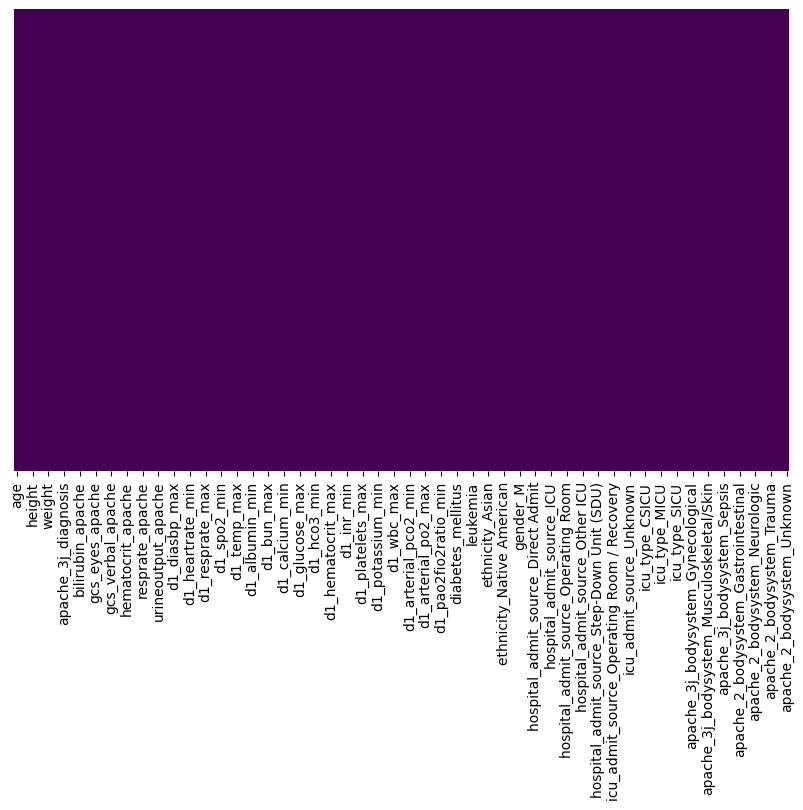

In [ ]:
# visualize null values for training data
plt.figure(figsize=(10, 6))
sns.heatmap(X_train_final.isnull(), yticklabels=False, cmap='viridis', cbar=False)

## Task 3: Class Imbalance

Visualizing the class imbalance

<Axes: xlabel='hospital_death'>

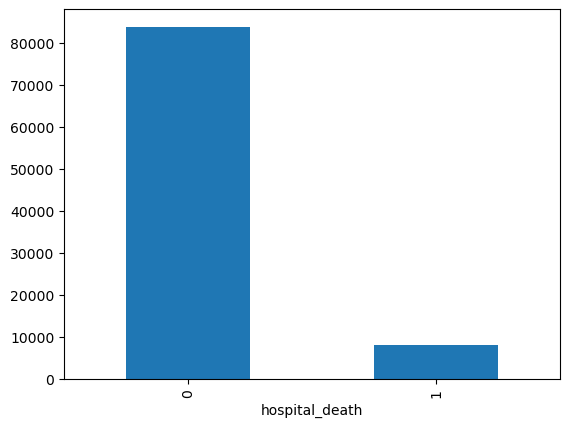

In [ ]:
y.value_counts().plot.bar()

Oversampling the data to handle the class imbalance. 

In [10]:
ros = RandomOverSampler(random_state=0)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_final, y_train)

Visualize the new data

<Axes: xlabel='hospital_death'>

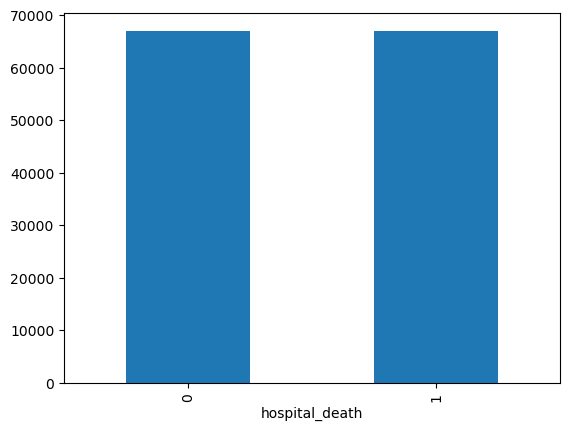

In [ ]:
pd.Series(y_train_resampled).value_counts().plot.bar()

## Task 4: Model training

In [11]:
log_model = LogisticRegression(max_iter=100, random_state=42)
log_model.fit(X_train_resampled, y_train_resampled)

c:\Users\isse_\miniconda3\envs\icu_lab\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test_final)

knn_model = KNeighborsClassifier(n_neighbors=5) 
knn_model.fit(X_train_scaled, y_train_resampled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
y_prob = rf_model.predict_proba(X_test_final)[:, 1]
threshold = 0.20
y_pred = (y_prob >= threshold).astype(int)
#y_pred = rf_model.predict(X_test_final)

print("--- Random Forest ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.3f}")
print(f"Recall Score: {recall_score(y_test, y_pred):.3f}")

y_pred_lr = log_model.predict(X_test_scaled)

print("\n--- Logistic Regression ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall Score: {recall_score(y_test, y_pred_lr):.3f}")

y_pred_knn = knn_model.predict(X_test_scaled)

print("\n--- K-Nearest Neighbors ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred_knn):.3f}")
print(f"Recall Score: {recall_score(y_test, y_pred_knn):.3f}")


--- Random Forest ---
Accuracy Score: 0.849
Precision Score: 0.329
Recall Score: 0.726

--- Logistic Regression ---
Accuracy Score: 0.820
Precision Score: 0.281
Recall Score: 0.696


c:\Users\isse_\miniconda3\envs\icu_lab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



--- K-Nearest Neighbors ---
Accuracy Score: 0.866
Precision Score: 0.300
Recall Score: 0.412


My best performing model was the Random Forest. It might not have had the highest Accuracy but it had the highest Recall Score, which means that it was the best at pinpointing what patients might die which I feel was the most important factor. 

In [ ]:
date_str = datetime.datetime.now().strftime("%y%m%d%H%M")

filename = f"models/randomforest_85_{date_str}.joblib"

joblib.dump(rf_model, filename)

['models/randomforest_85_2602071835.joblib']

Comparison, without Imputation

In [ ]:
mortality_dropped = mortality.dropna()

X_drop = mortality_dropped.drop('hospital_death', axis=1)
y_drop = mortality_dropped['hospital_death']

X_drop = pd.get_dummies(X_drop, drop_first=True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_drop, y_drop, test_size=0.2, random_state=0)

rf_drop = RandomForestClassifier(n_estimators=100, random_state=42)
rf_drop.fit(X_train_d, y_train_d)

y_prob_drop = rf_drop.predict_proba(X_test_d)[:, 1]
y_pred_drop = (y_prob_drop >= 0.20).astype(int)

print("\n--- Random Forest Without Imputation ---")
print(f"Accuracy Score: {accuracy_score(y_test_d, y_pred_drop):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred_knn):.3f}")
print(f"Recall Score: {recall_score(y_test_d, y_pred_drop):.3f}")


--- Random Forest Without Imputation ---
Accuracy Score: 0.630
Precision Score: 0.300
Recall Score: 0.924


Here we can see that the Recall score increased compared to our previous model that actually had used imputation. The reason for that could be that because we dropped all our rows that had missing data and because of that we only had patients left with "perfect" data. Beyond that we can also see that Accuracy dropped quite drastically, which means that our model just became more pessimistic and started guessing "Death" for more patients.

Comparison, without Class Balancing

In [ ]:
rf_no_ros = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_ros.fit(X_train_final, y_train)

y_prob_no_ros = rf_no_ros.predict_proba(X_test_final)[:, 1]
y_pred_no_ros = (y_prob_no_ros >= 0.20).astype(int)

print("\n--- Random Forest Without Class Balancing ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_no_ros):.3f}")
print(f"Precision Score: {precision_score(y_test, y_pred_no_ros):.3f}")
print(f"Recall Score: {recall_score(y_test, y_pred_no_ros):.3f}")


--- Random Forest Without Class Balancing ---
Accuracy Score: 0.878
Precision Score: 0.380
Recall Score: 0.658


Here we see that the test without class balancing had the highest accuracy and that is presumably because of the lack of balancing and the model leaning towards the class with more datapoints (alive). We can see that by the fact that the Recall and Precision score is lower. 

## Task 5: Feature Importance

Since Random Forest was the best model we use it to check what features had the most importance. What is great is that it already has a function to bring up that information. 

In [ ]:
importances = rf_model.feature_importances_

feature_names = X_train_resampled.columns

df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

df_importances = df_importances.sort_values(by='Importance', ascending=False)


print(df_importances.head(10))

                Feature  Importance
16     gcs_motor_apache    0.032691
41         d1_sysbp_min    0.031918
28    ventilated_apache    0.029117
15      gcs_eyes_apache    0.027876
64       d1_lactate_max    0.027046
39          d1_spo2_min    0.023231
48           d1_bun_max    0.022556
9   apache_3j_diagnosis    0.021706
18    gcs_verbal_apache    0.020757
35           d1_mbp_min    0.020636


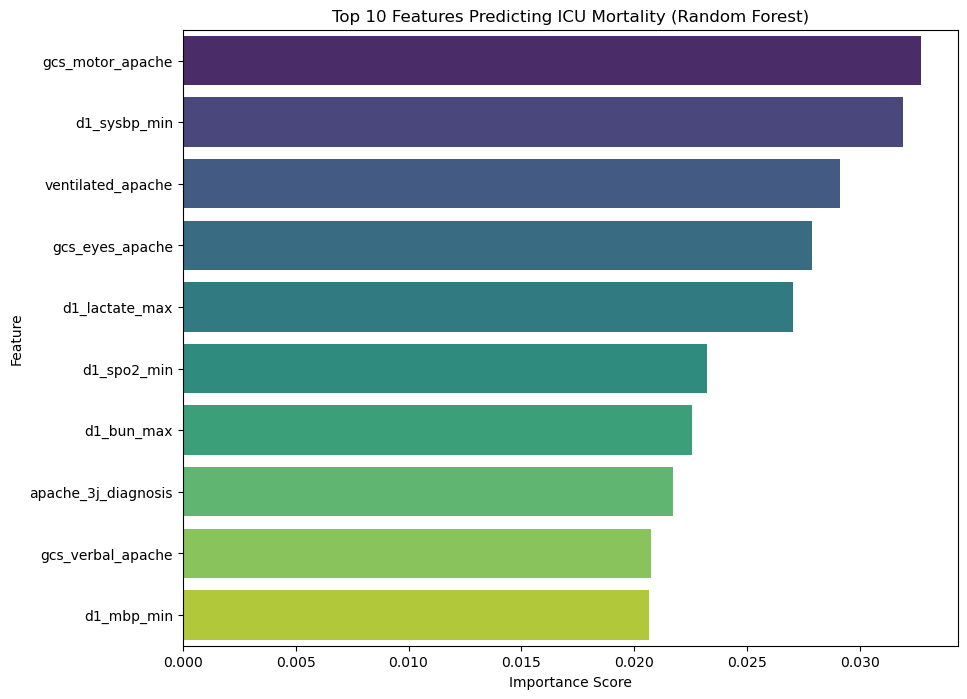

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x='Importance', 
    y='Feature',
    hue='Feature',
    data=df_importances.head(10), 
    palette='viridis'
)

plt.title('Top 10 Features Predicting ICU Mortality (Random Forest)')
plt.xlabel('Importance Score')
plt.legend=False
plt.show()